<a href="https://colab.research.google.com/github/rickycarrillo3/ML-Projects/blob/main/Diffusion_Model_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Simple Diffusion Model Demo**

Hello! Today we will learn about simple diffusion models. Diffusion models are generative models that learn to create data by reversing a gradual noising process. They are used in many current applications and models involving generative AI. When combined with CLIP embeddings, the composition is able to produce new images from text.

The first half of this video explains the overall process quite well: https://www.youtube.com/watch?v=firXjwZ_6KI&t=1s$0

## 1. Mathematical Foundation

### **Forward Diffusion (Encoding)**
We start with a real image $x_0$. Over $T$ time steps, we gradually add small amounts of Gaussian noise $\epsilon \sim \mathcal{N}(0,I)$. The distribution $q$ of the image at step $t$, given the image at step $t-1$, is:

$$q(x_t | x_{t-1}) = \mathcal{N}(x_t; \sqrt{1 - \beta_t} x_{t-1}, \beta_t I)$$

Where $\beta_t$ is a variance schedule (how much noise we add at step $t$).

**NOTE**: $\mathcal{N}(x_t; \sqrt{1 - \beta_t} x_{t-1}, \beta_t I)$ just means that $x_t$ is a normal random variable with mean $\sqrt{1 - \beta_t} x_{t-1}$ and covariance  matrix $\beta_t I$ where $I$ is the identity matrix. Simply put, we have

$$x_t= \sqrt{1 - \beta_t}x_{t-1} + \sqrt{\beta_t}\epsilon$$

where $\epsilon \sim \mathcal{N}(0,I)$

A nice property of Gaussian distributions allows us to jump directly to any time step $t$ without iterating, using $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$:

**NOTE**: Try this with $x_2$, $x_1$, and $x_0$ and see that this follows

$$q(x_t | x_0) = \mathcal{N}(x_t; \sqrt{\bar{\alpha}_t} x_0, (1 - \bar{\alpha}_t) I)$$

### **Backward Diffusion (Decoding)**
The reverse process aims to denoise the image step-by-step from $x_T$ (pure noise) back to $x_0$. Since the exact reverse step $q(x_{t-1} | x_t)$ depends on the entire data distribution, we approximate it using a neural network with parameters $\theta$:

$$p_\theta(x_{t-1} | x_t) = \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \Sigma_\theta(x_t, t))$$

where $\mu_{\theta}$ and $\Sigma_{\theta}$ are the mean and covariance matrix, respectively.

In practice, instead of predicting the mean directly, the network $\epsilon_\theta(x_t, t)$ predicts the *noise* that was added to the image.

## 2. Conceptual Questions

**Why use many time steps instead of just one?**
If we tried to map pure noise to a real image in a single step, the neural network would have to learn an incredibly complex, highly non-linear mapping all at once. By breaking the process down into hundreds of tiny steps, each individual step represents a very slight, simple transformation. Mathematically, if the step size is small enough, the reverse distribution $q(x_{t-1} | x_t)$ takes the form of a simple Gaussian, making it easy for a neural network to model. This is more complex than just this claim, but think of it like this for now.

**How do we determine how many time steps to use?**
The number of time steps $T$ is a hyperparameter (often between 100 and 1000). We determine it based on a trade-off: more steps make the assumption that each step is Gaussian more accurate (leading to higher quality, more stable generation), but it also linearly increases the computational time required to generate an image. Researchers usually tune this empirically based on the dataset complexity and compute budget.

**Why is the variance of $x_T$ chosen to be 1?**
The variance schedule $\beta_t$ is designed such that the cumulative product $\bar{\alpha}_T \approx 0$. If we look at the distribution $q(x_t | x_0)$, as $t \to T$, the mean $\sqrt{\bar{\alpha}_T} x_0$ approaches 0, and the variance $(1 - \bar{\alpha}_T)$ approaches 1. This ensures that the final state $x_T$ is essentially pure Standard Gaussian noise $\mathcal{N}(0, I)$. This is practically required because to generate *new* data out of thin air, we need a known, easily samplable distribution to start from. Starting with a variance of 1 gives us standard normal noise as our canvas.

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters for the demo
batch_size = 64
image_size = 32 # CIFAR-10 images are 32x32
channels = 3 # RGB
T = 200 # Number of diffusion steps (keep it small for the demo to run quickly)

# Load CIFAR-10 Dataset (Contains Animals, Vehicles, etc.)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize to [-1, 1] for 3 channels
])

dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

Using device: cuda


 26%|██▌       | 44.5M/170M [18:42<52:15, 40.2kB/s]

### 3. Forward Diffusion (Encoding)
Let's define the noise scheduler and visualize the forward diffusion process.

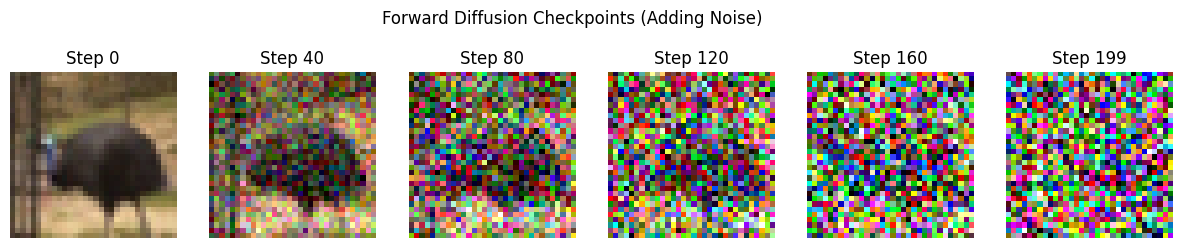

In [ ]:
# Define the forward diffusion schedule
betas = torch.linspace(1e-4, 0.02, T).to(device) # Linear beta schedule
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)

def forward_diffusion(x_0, t):
    """
    Adds noise to the image x_0 at time step t.
    x_0: original images
    t: target time steps
    """
    noise = torch.randn_like(x_0)
    # Get the cumulative alpha for the specific time steps
    sqrt_alphas_cumprod_t = torch.sqrt(alphas_cumprod[t])[:, None, None, None]
    sqrt_one_minus_alphas_cumprod_t = torch.sqrt(1. - alphas_cumprod[t])[:, None, None, None]

    # Equation: q(x_t | x_0) = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * noise
    x_t = sqrt_alphas_cumprod_t * x_0 + sqrt_one_minus_alphas_cumprod_t * noise
    return x_t, noise

# --- Visualizing Forward Diffusion Checkpoints ---
images, _ = next(iter(dataloader))
images = images.to(device)

# Select a few time steps to visualize
time_steps_to_show = [0, 40, 80, 120, 160, 199]

plt.figure(figsize=(15, 3))
for i, t in enumerate(time_steps_to_show):
    t_tensor = torch.tensor([t]).to(device)
    noised_image, _ = forward_diffusion(images[0:1], t_tensor)

    # Unnormalize for visualization
    img_vis = noised_image[0].cpu().numpy()
    img_vis = (img_vis + 1) / 2
    img_vis = np.clip(img_vis, 0, 1)
    img_vis = np.transpose(img_vis, (1, 2, 0)) # Change to HWC for matplotlib

    plt.subplot(1, len(time_steps_to_show), i + 1)
    plt.imshow(img_vis)
    plt.title(f"Step {t}")
    plt.axis('off')
plt.suptitle("Forward Diffusion Checkpoints (Adding Noise)")
plt.show()

### 4. Backward Diffusion Network
We'll use a very simple Multi-Layer Perceptron (MLP) for this demonstration to predict the noise $\epsilon_\theta(x_t, t)$. In production, a U-Net architecture is standard.

In [ ]:
class SimpleDiffusionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # A simple network that takes the flattened image and the time step as input
        # 3 channels * 32 width * 32 height = 3072 features
        self.time_embedding = nn.Embedding(T, 128)
        self.network = nn.Sequential(
            nn.Linear(3*32*32 + 128, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 3*32*32)
        )

    def forward(self, x, t):
        # Flatten image
        x_flat = x.view(x.size(0), -1)
        # Embed time
        t_emb = self.time_embedding(t)
        # Concatenate image features and time embedding
        input_features = torch.cat([x_flat, t_emb], dim=1)
        # Predict noise
        predicted_noise = self.network(input_features)
        # Reshape back to image dimensions
        return predicted_noise.view(x.size(0), 3, 32, 32)

model = SimpleDiffusionMLP().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.5e-3)
loss_fn = nn.MSELoss()

### 5. Training the Backward Diffusion
We train the model to predict the exact noise we added during the forward step.

In [ ]:
# Train for just a few epochs for demonstration purposes
# Around 4:15 mins for 20 epochs on A100 GPU
epochs = 200

model.train()
for epoch in range(epochs):
    total_loss = 0
    for batch_idx, (x_0, _) in enumerate(dataloader):
        x_0 = x_0.to(device)

        # 1. Sample random time steps for the batch
        t = torch.randint(0, T, (batch_size,), device=device).long()

        # 2. Add noise to the images (Forward step)
        x_t, actual_noise = forward_diffusion(x_0, t)

        # 3. Predict the noise using our model (Backward step learning)
        predicted_noise = model(x_t, t)

        # 4. Compute loss and optimize
        loss = loss_fn(predicted_noise, actual_noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 200 == 0 and epoch % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Batch {batch_idx} | Loss: {loss.item():.4f}")

    print(f"--- Epoch {epoch+1} Average Loss: {total_loss/len(dataloader):.4f} ---")

### 6. Final Generation Step (Sampling)
Now we start from pure noise and iteratively denoise it using the trained model.

Since we are using an MLP, training over a few hundred epochs will leave us with some colorful blobs that sort of resemble objects. However, because spatial relationships are not maintained in a simple MLP, we will never see precise, real images. For this, we need to use a convolutional approach.

In [ ]:
@torch.no_grad()
def generate_images(model, num_images=5):
    model.eval()
    # Start with pure Gaussian noise
    x = torch.randn((num_images, 3, 32, 32)).to(device)

    checkpoints = []

    # Iterate backwards from T-1 to 0
    for t in reversed(range(0, T)):
        t_tensor = torch.full((num_images,), t, device=device, dtype=torch.long)

        # Model predicts the noise
        predicted_noise = model(x, t_tensor)

        # Get schedule variables for current step
        alpha_t = alphas[t]
        alpha_cumprod_t = alphas_cumprod[t]
        beta_t = betas[t]

        # Compute the mean of the previous step x_{t-1}
        # Equation: mu_theta = (1/sqrt(alpha_t)) * (x_t - (beta_t / sqrt(1 - alpha_bar_t)) * predicted_noise)
        mean = (1.0 / torch.sqrt(alpha_t)) * (x - ((1.0 - alpha_t) / torch.sqrt(1.0 - alpha_cumprod_t)) * predicted_noise)

        if t > 0:
            # Add a small amount of random noise back in (Langevin dynamics)
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(beta_t) * noise
        else:
            # Final step, just use the mean
            x = mean

        # Save checkpoints for visualization
        if t in [199, 150, 100, 50, 0]:
            checkpoints.append((t, x.clone()))

    return checkpoints

# Generate and visualize
print("Generating images...")
checkpoints = generate_images(model, num_images=1)

plt.figure(figsize=(15, 3))
for i, (t, img_tensor) in enumerate(checkpoints):
    img_vis = img_tensor[0].cpu().numpy()
    img_vis = (img_vis + 1) / 2 # Unnormalize
    img_vis = np.clip(img_vis, 0, 1)
    img_vis = np.transpose(img_vis, (1, 2, 0)) # Change to HWC for matplotlib

    plt.subplot(1, len(checkpoints), i + 1)
    plt.imshow(img_vis)
    plt.title(f"Step {t} (Denoising)")
    plt.axis('off')
plt.suptitle("Backward Diffusion Checkpoints (Generation from Noise)")
plt.show()